# WM-811K 분할 전 EDA

canonical 구조·품질을 로컬에서 확인합니다. 원본 pickle, 라벨 수정, 충돌 제외, 분할, resize, 증강, 모델 학습은 실행하지 않습니다.

노트북·CLI·향후 에이전트는 `src/wafer_dl/eda.py`의 같은 코어를 사용합니다. 현재 에이전트 실행기·LLM 연결은 미구현이며 EDA 코어만 호출 가능한 상태입니다.

**출력에는 실제 집계·이미지가 포함됩니다. LLM·외부 추적에 보내지 말고 Git 공유 전 모든 셀 출력을 지우세요.** 전체 데이터 EDA는 구조·품질 확인용입니다. 입력 해상도·증강 선택은 분할 후 Train/Validation에서 진행합니다.

먼저 canonical 정합성 검사를 통과한 묶음을 사용하세요. EDA는 전체 NPZ 정합성 검사를 대신하지 않습니다.

In [1]:
# ==========================================
# 노트북 실행 위치와 무관하게 프로젝트 루트 확인
# - 작업 폴더는 변경하지 않고 import 경로만 추가
# - 코어는 원본 pickle을 읽지 않음
# ==========================================
from pathlib import Path
import sys
import json

project_root = next((p for p in (Path.cwd(), *Path.cwd().parents)
                     if (p / 'src/wafer_dl/eda.py').is_file()), None)
if project_root is None:
    raise RuntimeError('프로젝트 내부에서 노트북을 실행하세요.')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from IPython.display import display
import matplotlib.pyplot as plt
from src.wafer_dl.eda import (
    load_eda_metadata, summarize_metadata, select_example_positions,
    load_example_maps, plot_distributions, plot_die_statistics, plot_examples, run_eda,
)
print('공통 EDA 코어 준비 완료. 아직 데이터를 읽지 않았습니다.')

공통 EDA 코어 준비 완료. 아직 데이터를 읽지 않았습니다.


## 1. 새 canonical 묶음 선택

`CANONICAL_DIR`에 실제 폴더 경로를 입력할 수 있습니다. `None`이면 수정 라벨 버전의 후보가 하나일 때만 자동 선택합니다. 여러 후보에서 최신 폴더를 임의로 선택하지 않습니다.

In [2]:
# 실제 폴더를 직접 선택하려면 None 대신 경로 문자열을 넣으세요.
CANONICAL_DIR = None

if CANONICAL_DIR is None:
    base = project_root / 'data/processed/wm811k/canonical'
    candidates = []
    from src.wafer_dl.validate_canonical import read_json
    for folder in sorted(base.glob('canonical_*')):
        if folder.is_dir() and (folder / 'SUCCESS.json').is_file():
            if read_json(folder / 'conversion.json').get('label_normalization_version') == 'wm_label_v2':
                candidates.append(folder)
    if len(candidates) != 1:
        print('수정 버전 후보 폴더:', [p.name for p in candidates])
        raise ValueError('후보가 하나가 아닙니다. CANONICAL_DIR에 실제 폴더를 지정하세요.')
    canonical_dir = candidates[0]
else:
    canonical_dir = Path(CANONICAL_DIR)
    if not canonical_dir.is_absolute():
        canonical_dir = project_root / canonical_dir

metadata = load_eda_metadata(canonical_dir)
tables = summarize_metadata(metadata)
print('metadata 집계 완료. 맵 배열은 아직 읽지 않았습니다.')

metadata 집계 완료. 맵 배열은 아직 읽지 않았습니다.


## 2. 클래스·미라벨·격리·중복 요약

- `labeled_samples`와 `accepted_labeled_samples`를 구분합니다. 
- 미라벨은 정상 `None`으로 취급하지 않습니다. 
- 같은 맵 내용의 중복은 같은 실물 웨이퍼의 복제라고 단정할 수 없습니다. 
- Lot 수는 독립 연결 그룹 수와 다릅니다. 
- 연결 그룹 상세 진단은 `diagnose_split` 보고서를 함께 보세요.

In [3]:
display(tables['classes'])
display(tables['statuses'])
display(tables['statistics'])
display(tables['shapes'].head(20))
display(tables['lot_sizes'].describe())

,labeled_samples,accepted_labeled_samples,accepted_lot_count
pattern_label,,,
None,147431,147431,6591
Center,4294,4294,1648
Donut,555,555,233
Edge-Loc,5189,5189,3211
Edge-Ring,9680,9680,1075
Loc,3593,3593,2472
Near-Full,149,149,137
Random,866,866,449
Scratch,1193,1193,1059


,,rows
label_status,quality_status,
labeled,accepted,172950
unlabeled,accepted,638507


{'row_count': 811457,
 'rows_with_valid_map': 811457,
 'lot_count': 46293,
 'duplicate_map_groups': 32630,
 'rows_in_duplicate_groups': 147488,
 'map_label_conflict_groups': 14,
 'split_complete': False,
 'training_ready': False}

,map_height,map_width,rows
88,32,29,108687
34,25,27,64083
255,49,39,39323
38,26,26,30078
77,30,34,29513
102,33,33,23886
98,33,29,20276
162,39,37,15327
292,52,59,14812
84,31,31,14569


count    46293.000000
mean        17.528719
std          8.964477
min          1.000000
25%         10.000000
50%         24.000000
75%         25.000000
max         25.000000
Name: rows_per_lot, dtype: float64

## 3. 분포 그림

- 클래스·상태 건수는 로그축으로 다수/희소 그룹을 함께 확인합니다. 
- 맵 크기·종횡비는 resize 전 구조입니다. 
- 불량 다이 비율은 유효 다이 중 값 2의 비율이며 SECOM 불량 확률과 다릅니다.

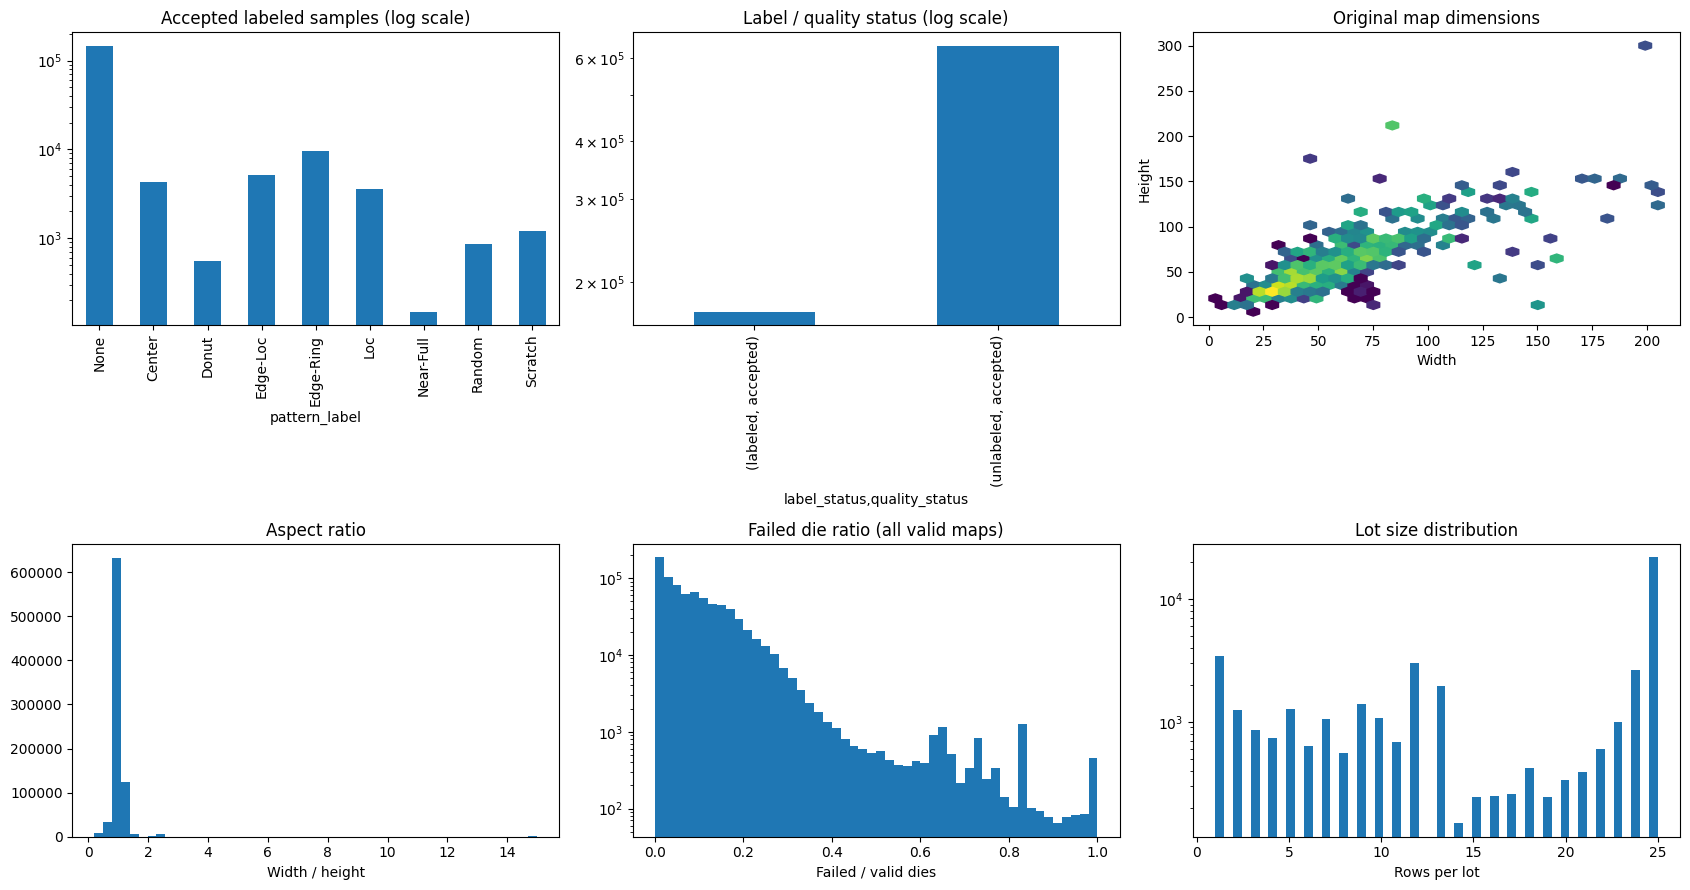

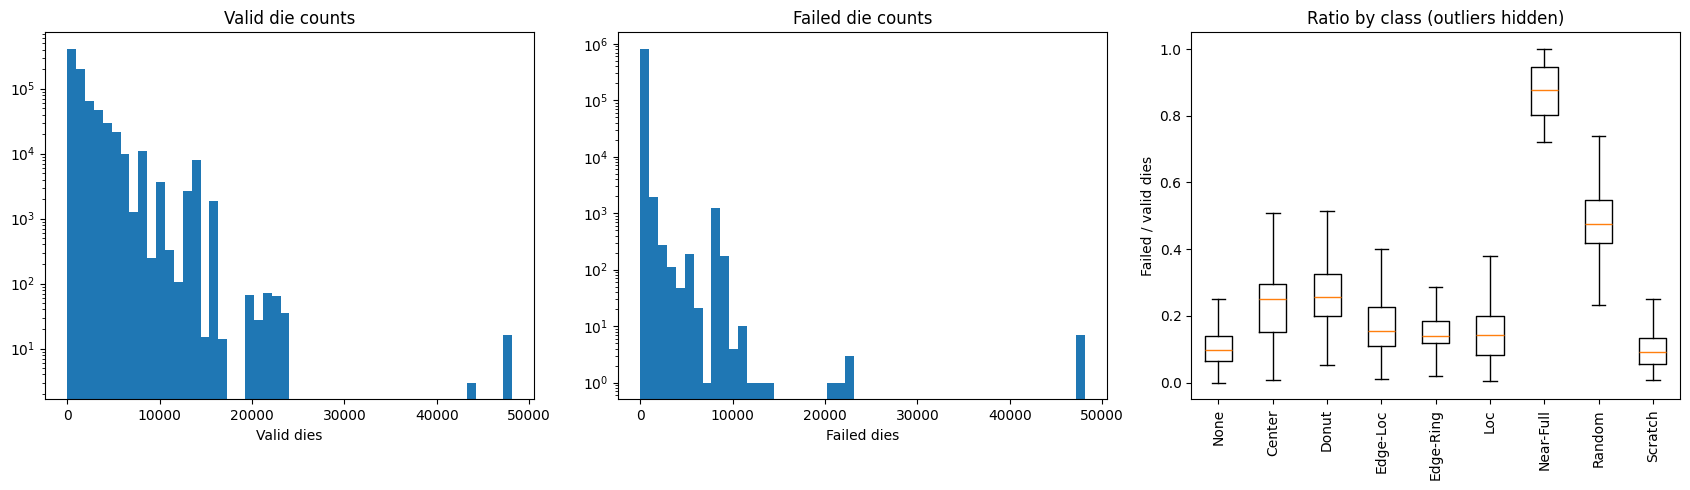

In [4]:
figure = plot_distributions(metadata, tables)
plt.show()
plt.close(figure)
figure = plot_die_statistics(metadata)
plt.show()
plt.close(figure)

## 4. 수치 metadata 상관분석

- accepted 유효 맵의 완전 관측 행(미라벨 포함)으로 Spearman·Pearson을 비교합니다. 
- 클래스 번호·Lot·해시·행 번호는 제외합니다.
- 상수 열·3건 미만은 N/A입니다. 
- 전체 계수는 클래스 구성·중복·Lot의 영향을 받으며 독립 표본 검정이 아닙니다.
- 불량 비율=불량 다이 수/유효 다이 수이므로 계산상 연관에 주의하세요. 
- 상관은 인과관계나 자동 특징 선택 근거가 아닙니다. 모델용 선택은 분할 후 Train에서 검토합니다.
- 산점도만 최대 5,000건을 고정 추출하며 클래스 균형 표본이 아닙니다. 
- 표·그림은 로컬 전용입니다.

,rows
all_accepted,811457


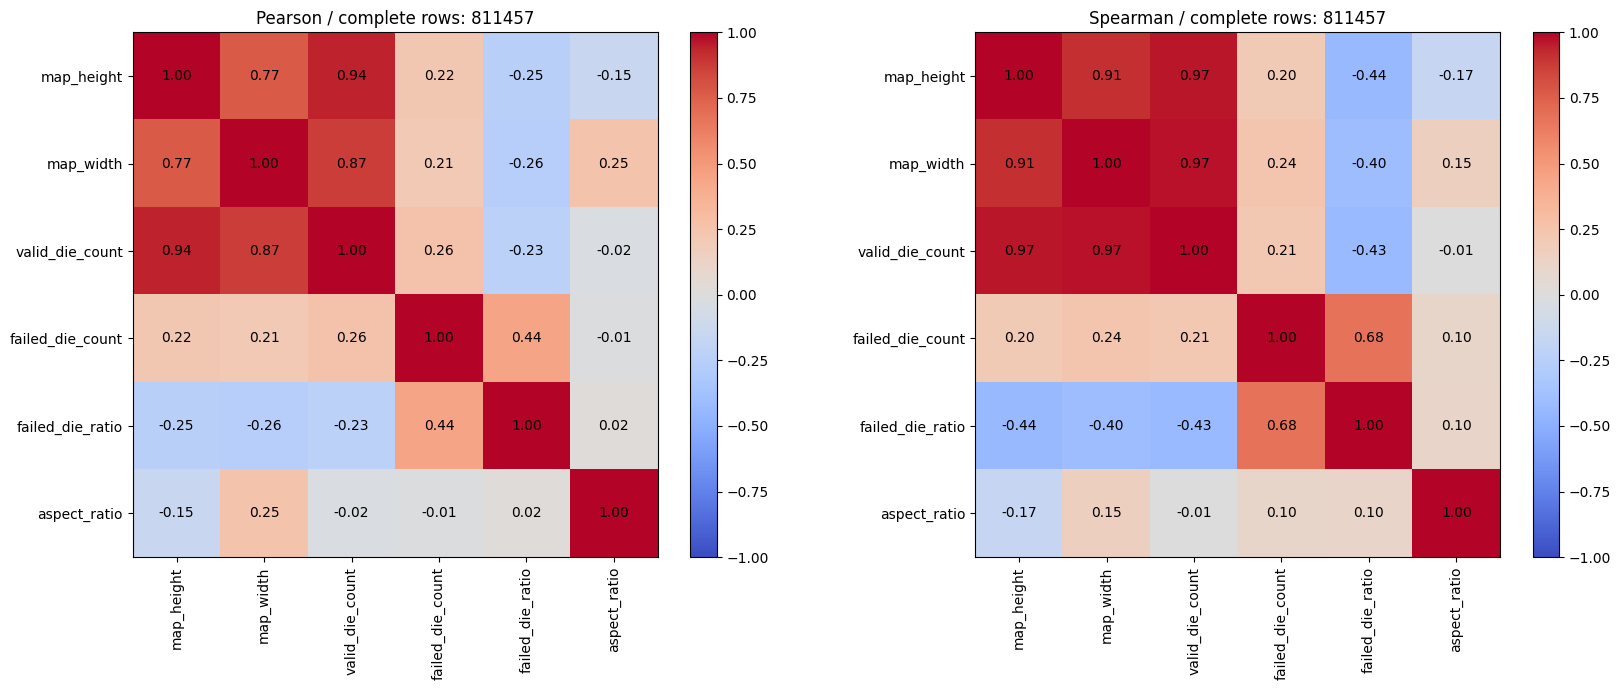

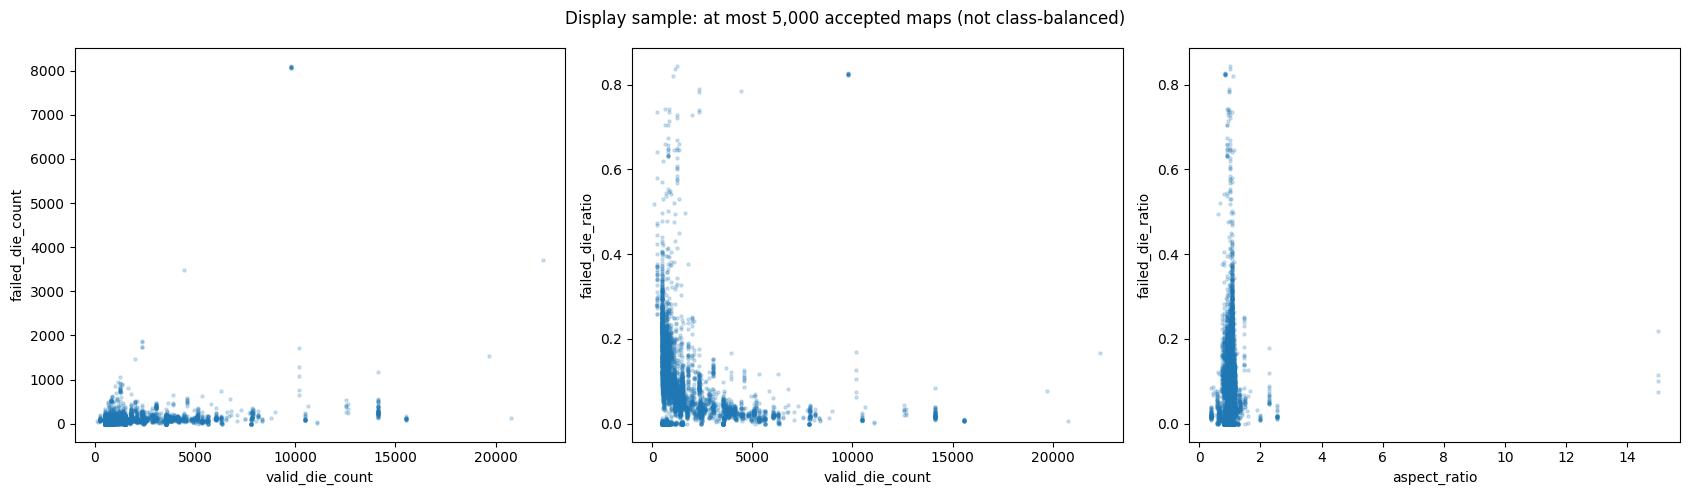

,pattern_label,method,first,second,rows,correlation
10,None,pearson,valid_die_count,failed_die_ratio,147431,-0.444934
25,None,spearman,valid_die_count,failed_die_ratio,147431,-0.703998
40,Center,pearson,valid_die_count,failed_die_ratio,4294,-0.389056
55,Center,spearman,valid_die_count,failed_die_ratio,4294,-0.596383
70,Donut,pearson,valid_die_count,failed_die_ratio,555,0.224154
85,Donut,spearman,valid_die_count,failed_die_ratio,555,0.127126
100,Edge-Loc,pearson,valid_die_count,failed_die_ratio,5189,-0.278933
115,Edge-Loc,spearman,valid_die_count,failed_die_ratio,5189,-0.517977
130,Edge-Ring,pearson,valid_die_count,failed_die_ratio,9680,-0.631286
145,Edge-Ring,spearman,valid_die_count,failed_die_ratio,9680,-0.770132


In [5]:
from src.wafer_dl.eda import summarize_correlations, plot_correlations, plot_correlation_scatter

# 전체 적격 행의 계수와 클래스별 표본 수를 확인합니다.
correlations = summarize_correlations(metadata)
display(correlations['support'])
figure = plot_correlations(correlations)
plt.show()
plt.close(figure)
figure = plot_correlation_scatter(metadata)
plt.show()
plt.close(figure)
# 우선 유효 다이 수와 불량 비율의 관계를 클래스별로 비교합니다.
class_correlations = correlations['by_class']
display(class_correlations.loc[
    class_correlations['first'].eq('valid_die_count') &
    class_correlations['second'].eq('failed_die_ratio')
])

## 5. 클래스별 원본 크기 예시

- 회색=웨이퍼 밖(0), 초록=정상 다이(1), 빨강=불량 다이(2). 
- 클래스별 첫 유효 1건만 확인하며 대표성이나 클래스 전체 특성을 보장하지 않습니다. 
- 이 셀만 소수의 NPZ 배열을 숫자 전용으로 읽습니다. 
- 예시를 보고 Test용 변환 설정을 최적화하지 않습니다.

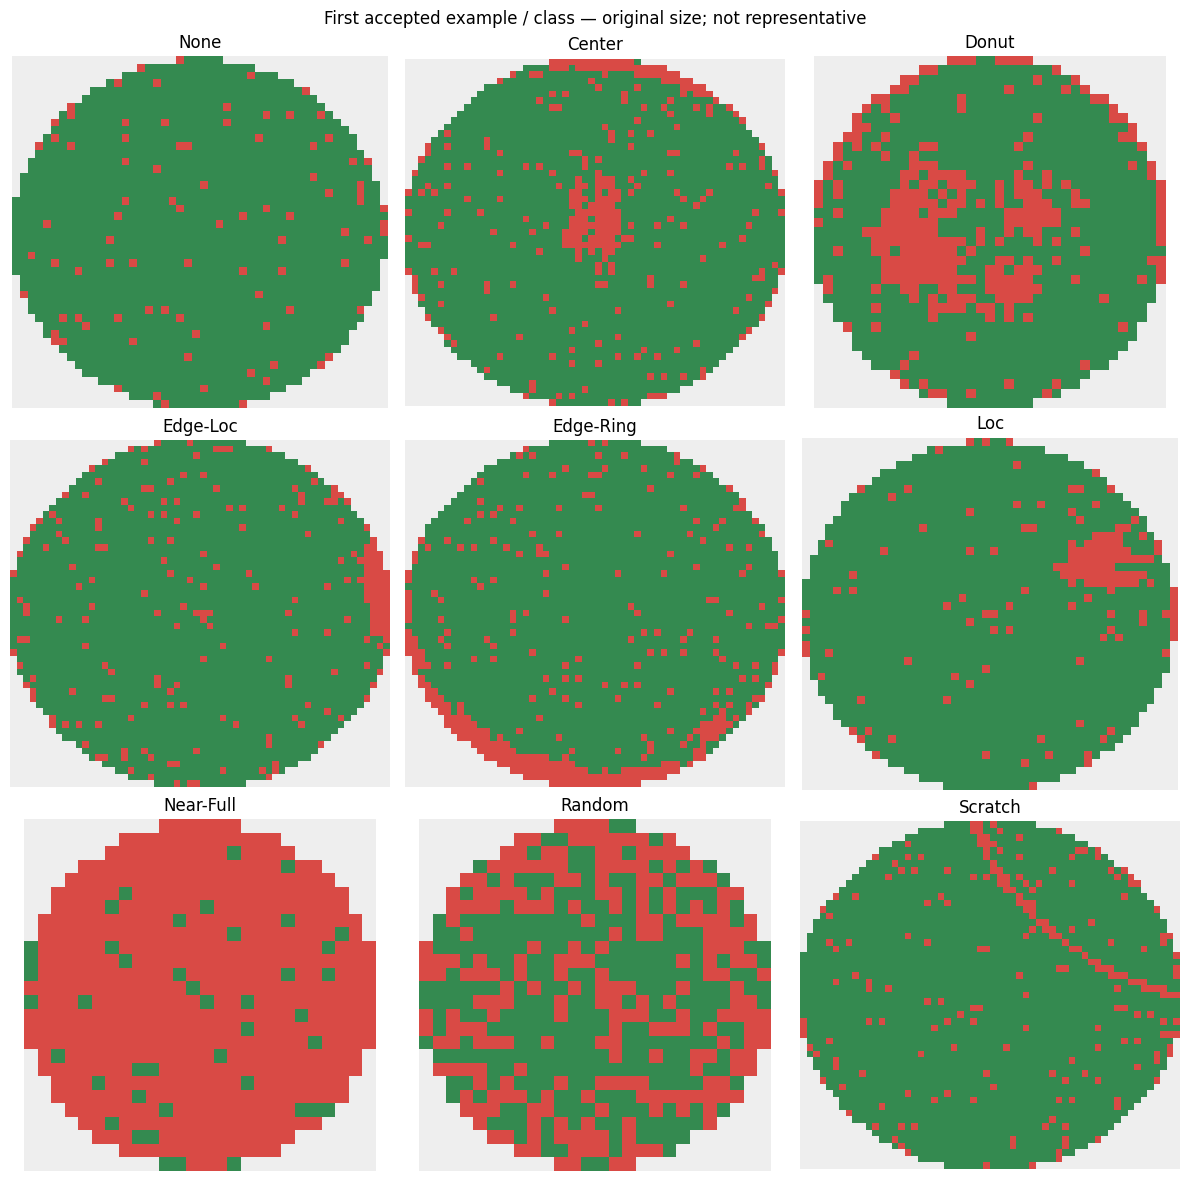

In [6]:
positions = select_example_positions(metadata)
examples = load_example_maps(canonical_dir, positions)
figure = plot_examples(examples)
plt.show()
plt.close(figure)

## 6. 로컬 보고서 저장 — 선택 실행

- `SAVE_REPORT=True`로 바꾸면 에이전트가 호출할 때와 동일한 `run_eda()`로 재집계·저장합니다. 
- 기존 폴더를 덮어쓰지 않으므로 실행마다 새 이름을 지정하세요. 
- 반환 상태는 로컬 실행용이며 현재 LLM 상태 계약에 자동 전달하지 않습니다.

In [7]:
SAVE_REPORT = False
OUTPUT_DIR = project_root / 'reports/wm811k/figures/eda_01'
if SAVE_REPORT:
    result = run_eda(canonical_dir, OUTPUT_DIR)
    print(result['status'])
else:
    print('보고서를 저장하지 않았습니다.')

보고서를 저장하지 않았습니다.


## 7. 로컬 검토 메모

- [ ] 9개 클래스가 존재하고 미라벨·격리와 구분되는지 확인
- [ ] 맵 크기·종횡비·다이 수의 극단값과 원본 패턴 확인
- [ ] 클래스별 불량 비율 차이와 희소 클래스 지원 확인
- [ ] 중복·라벨 충돌 제외 영향 진단 보고서 확인
- [ ] 제외 정책 승인 후 Lot·동일 맵 비중첩 분할로 진행

현재 단계에서는 모델 성능 결론·출하 판단·전체 파이프라인 정확도를 주장하지 않습니다.

## 8. 입력 변환 검증 결과

먼저 `python -m src.wafer_dl.check_transform --split-dir data/splits/wm811k/group_v1 --config configs/wm811k/transform.json --output-dir reports/wm811k/transform_v1`을 프로젝트 루트에서 직접 실행합니다. 아래 셀은 저장된 결과만 읽습니다.
불량·유효 영역 전체 소실이 없어도 Scratch 선이나 고리 모양이 보존되었는지 직접 비교하세요. 첫 사례와 극단 사례만 표시하며 Test 맵은 포함하지 않습니다. 비율 차이 0.01은 1%p입니다.
결과·그림은 로컬 전용이며 커밋 전에 출력 정보를 점검하세요.

In [ ]:
import pandas as pd
from IPython.display import Image, display
from src.wafer_dl.validate_canonical import read_json

# 실제 변환 검사는 별도 실행하고 여기서는 저장 완료된 결과만 확인합니다.
TRANSFORM_CHECK_DIR = project_root / 'reports/wm811k/transform_v1'
if (TRANSFORM_CHECK_DIR / 'SUCCESS.json').is_file():
    completion = read_json(TRANSFORM_CHECK_DIR / 'SUCCESS.json')
    if completion.get('status') != 'transform_check_complete':
        raise ValueError('변환 검사 완료 표식이 아닙니다.')
    transform_report = read_json(TRANSFORM_CHECK_DIR / 'transform_check.json')
    print('검사 상태:', transform_report['status'])
    print('형태 보존 시각 검토는 별도로 필요합니다. 학습 준비 완료가 아닙니다.')
    display(pd.DataFrame(transform_report['classes']))
    display(Image(filename=str(TRANSFORM_CHECK_DIR / 'examples.png')))
else:
    print('저장된 변환 검사 결과가 없습니다. 안내된 명령을 먼저 실행하세요.')